# Proyecto Final - Análisis de Datos
## Predicción de Precios de Alquiler en Estados Unidos

**Dataset:** Apartamentos en Alquiler (USA) - Tema_9.csv  
**Objetivo:** Predecir el precio de alquiler según características del inmueble  
**Universidad de Montevideo**

---

In [25]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 4.3 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


---
## 1. Descripción del Problema

El mercado inmobiliario de alquileres en Estados Unidos presenta una gran variabilidad de precios que depende de múltiples factores.

**Objetivo:** Desarrollar un modelo que prediga el precio de alquiler basándose en:
- Características físicas (habitaciones, baños, tamaño)
- Ubicación geográfica (estado, ciudad, coordenadas)
- Comodidades y servicios

---
## 2. Descripción del Conjunto de Datos

In [4]:
# Cargar el dataset
# IMPORTANTE: Asegúrate de que el archivo Tema_9.csv esté en el mismo directorio
df = pd.read_csv('Resources/Tema_9.csv', encoding = 'latin1', delimiter = ';')

print('='*80)
print('DATASET CARGADO')
print('='*80)
print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')

DATASET CARGADO
Dimensiones: 10,000 filas × 22 columnas

Columnas: ['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']


In [5]:
# Vista previa del dataset
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,790,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,NaN,425,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,1390,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,NaN,925,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,NaN,880,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [6]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

---
## 3. Análisis Exploratorio de Datos (EDA)

In [7]:
# Valores nulos
print('VALORES NULOS')
print('='*80)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje': nulos_pct
})
print(nulos_df[nulos_df['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False))

VALORES NULOS
              Valores Nulos  Porcentaje
pets_allowed           4163       41.63
amenities              3549       35.49
address                3327       33.27
cityname                 77        0.77
state                    77        0.77
bathrooms                34        0.34
latitude                 10        0.10
longitude                10        0.10
bedrooms                  7        0.07


In [8]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS')
print('='*80)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS


,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [9]:
# Análisis de la variable objetivo: PRECIO
print('VARIABLE OBJETIVO: PRICE')
print('='*80)
print(f'Precio Mínimo:        ${df["price"].min():>10,.2f}')
print(f'Precio Máximo:        ${df["price"].max():>10,.2f}')
print(f'Precio Promedio:      ${df["price"].mean():>10,.2f}')
print(f'Precio Mediana:       ${df["price"].median():>10,.2f}')
print(f'Desviación Estándar:  ${df["price"].std():>10,.2f}')

# Distribución geográfica
print('\n' + '='*80)
print('DISTRIBUCIÓN GEOGRÁFICA')
print('='*80)
print(f'Estados únicos:  {df["state"].nunique()}')
print(f'Ciudades únicas: {df["cityname"].nunique()}')

print('\nTop 10 Estados:')
print(df['state'].value_counts().head(10))

print('\nTop 10 Ciudades:')
print(df['cityname'].value_counts().head(10))

VARIABLE OBJETIVO: PRICE
Precio Mínimo:        $    200.00
Precio Máximo:        $ 52,500.00
Precio Promedio:      $  1,486.28
Precio Mediana:       $  1,270.00
Desviación Estándar:  $  1,076.51

DISTRIBUCIÓN GEOGRÁFICA
Estados únicos:  51
Ciudades únicas: 1574

Top 10 Estados:
state
TX    1737
CA     955
WA     519
NC     438
MD     424
NJ     383
GA     372
FL     339
OH     321
CO     318
Name: count, dtype: int64

Top 10 Ciudades:
cityname
Austin           523
Dallas           216
Houston          186
San Antonio      182
Los Angeles      165
Chicago          148
Madison          121
Portland         113
Denver           105
San Francisco    104
Name: count, dtype: int64


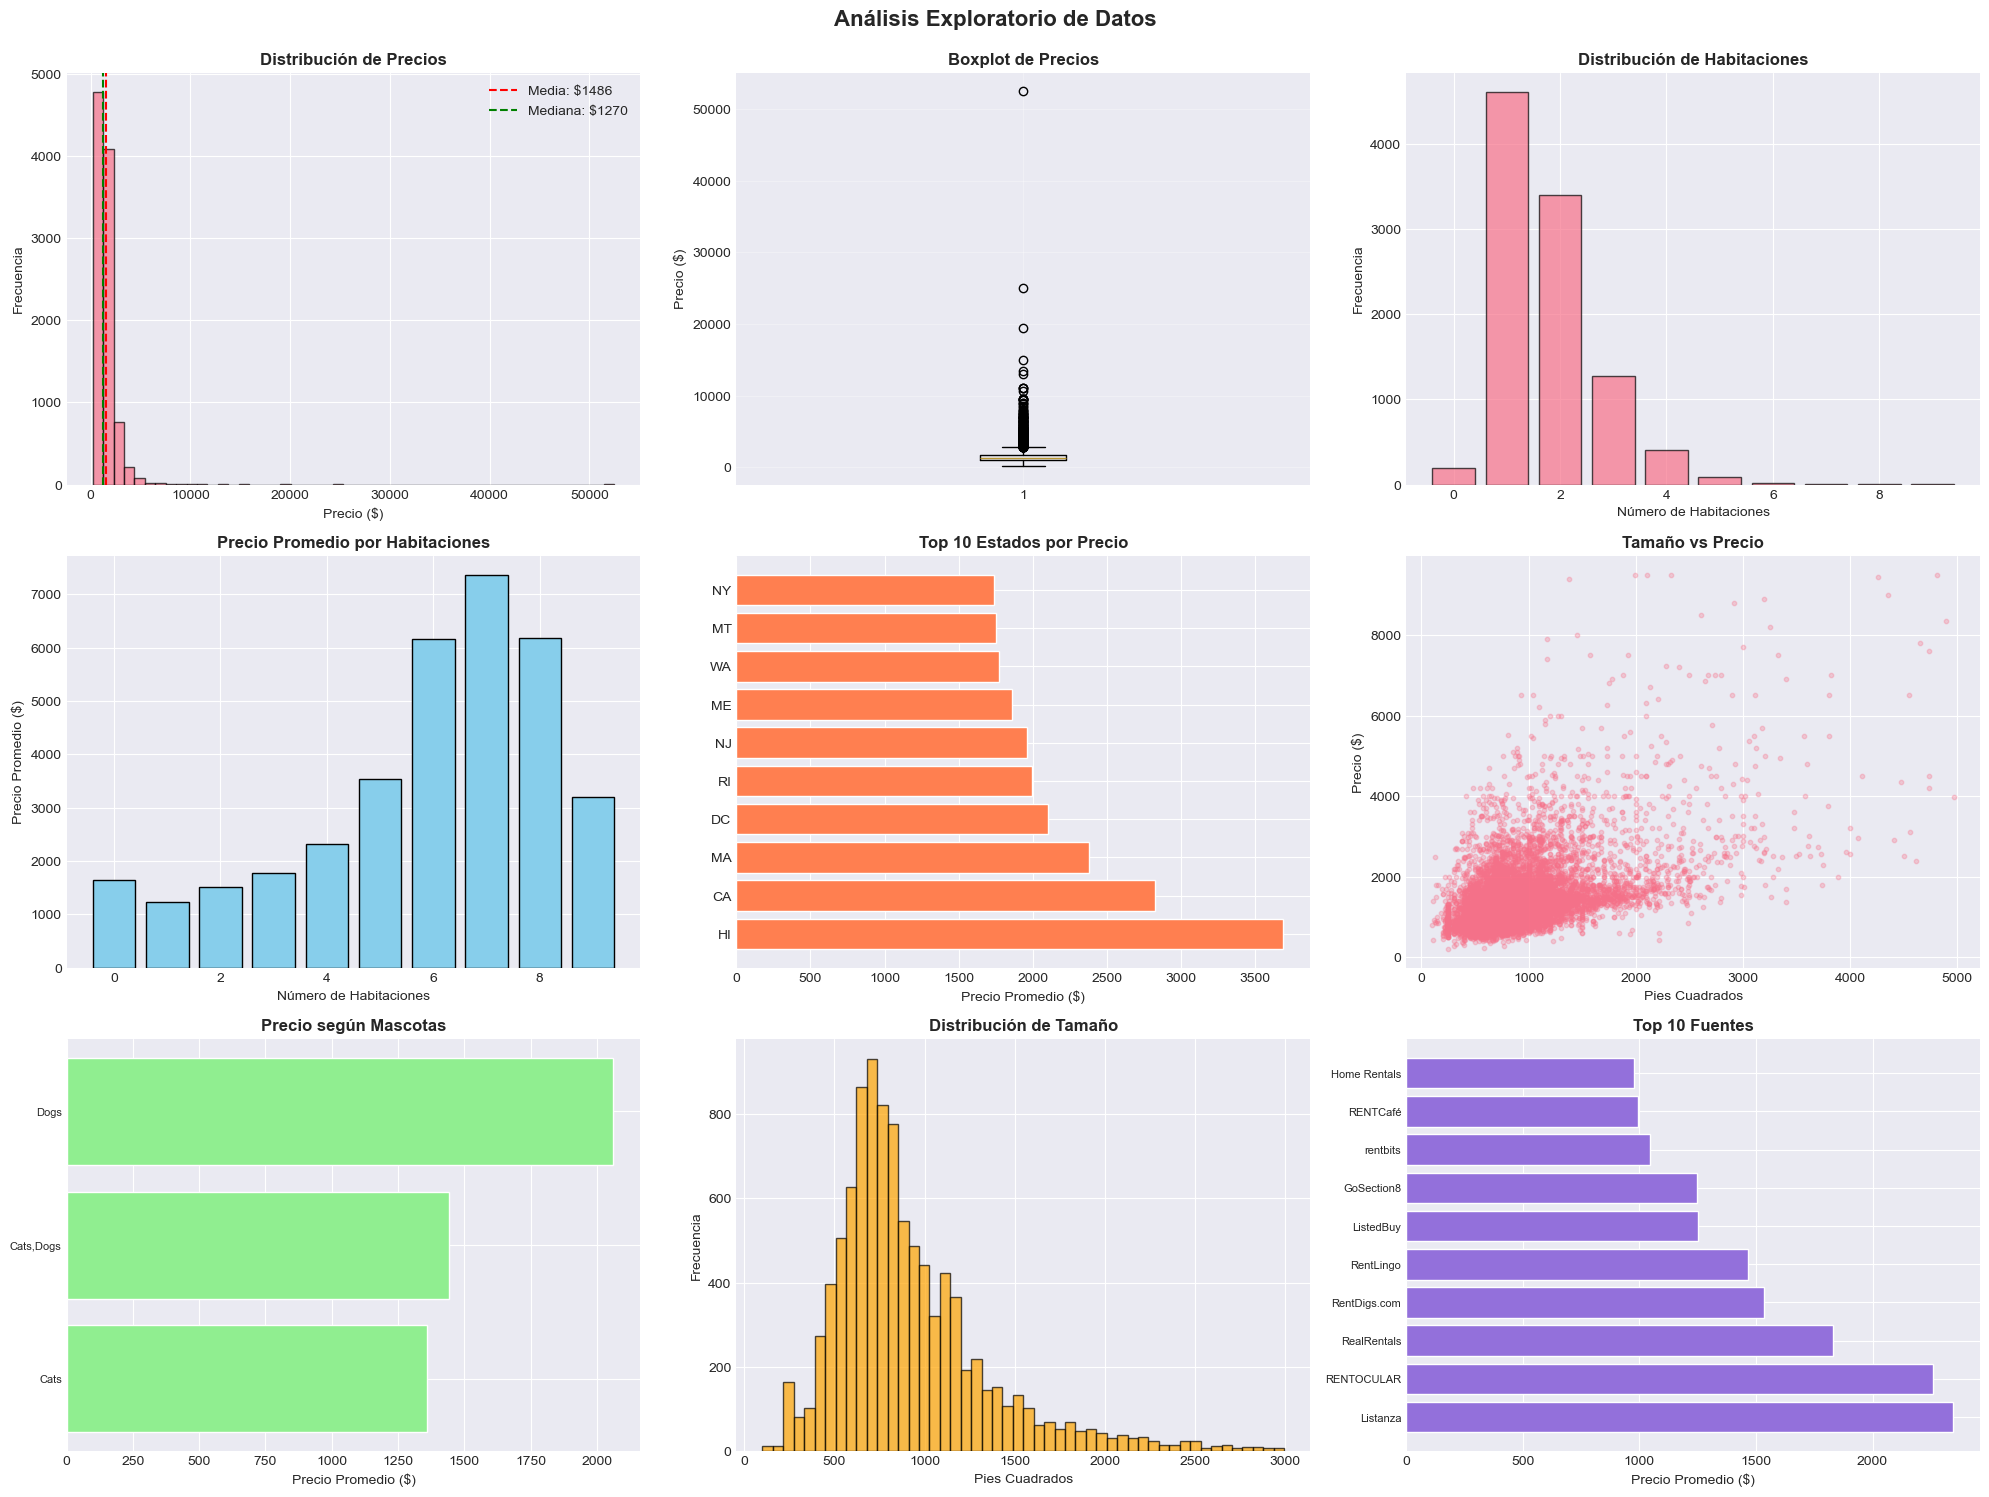

In [10]:
# Visualizaciones exploratorias
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Análisis Exploratorio de Datos', fontsize=16, fontweight='bold', y=0.995)

# 1. Distribución de precios
axes[0, 0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', 
                   label=f'Media: ${df["price"].mean():.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', 
                   label=f'Mediana: ${df["price"].median():.0f}')
axes[0, 0].set_xlabel('Precio ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Precios', fontweight='bold')
axes[0, 0].legend()

# 2. Boxplot de precios
axes[0, 1].boxplot(df['price'], vert=True)
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].set_title('Boxplot de Precios', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de bedrooms
bedrooms_counts = df['bedrooms'].value_counts().sort_index()
axes[0, 2].bar(bedrooms_counts.index, bedrooms_counts.values, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Número de Habitaciones')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Distribución de Habitaciones', fontweight='bold')

# 4. Precio promedio por bedrooms
price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_index()
axes[1, 0].bar(price_by_bedrooms.index, price_by_bedrooms.values, 
               color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Número de Habitaciones')
axes[1, 0].set_ylabel('Precio Promedio ($)')
axes[1, 0].set_title('Precio Promedio por Habitaciones', fontweight='bold')

# 5. Top 10 estados por precio promedio
top_states = df.groupby('state')['price'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(range(len(top_states)), top_states.values, color='coral')
axes[1, 1].set_yticks(range(len(top_states)))
axes[1, 1].set_yticklabels(top_states.index)
axes[1, 1].set_xlabel('Precio Promedio ($)')
axes[1, 1].set_title('Top 10 Estados por Precio', fontweight='bold')

# 6. Square Feet vs Precio
df_filtered = df[(df['square_feet'] < 5000) & (df['price'] < 10000)]
axes[1, 2].scatter(df_filtered['square_feet'], df_filtered['price'], alpha=0.3, s=10)
axes[1, 2].set_xlabel('Pies Cuadrados')
axes[1, 2].set_ylabel('Precio ($)')
axes[1, 2].set_title('Tamaño vs Precio', fontweight='bold')

# 7. Precio por pets_allowed
pets_data = df[df['pets_allowed'].notna()]
pets_price = pets_data.groupby('pets_allowed')['price'].mean().sort_values()
axes[2, 0].barh(range(len(pets_price)), pets_price.values, color='lightgreen')
axes[2, 0].set_yticks(range(len(pets_price)))
axes[2, 0].set_yticklabels(pets_price.index, fontsize=8)
axes[2, 0].set_xlabel('Precio Promedio ($)')
axes[2, 0].set_title('Precio según Mascotas', fontweight='bold')

# 8. Distribución de Square Feet
axes[2, 1].hist(df[df['square_feet'] < 3000]['square_feet'], bins=50, 
                edgecolor='black', alpha=0.7, color='orange')
axes[2, 1].set_xlabel('Pies Cuadrados')
axes[2, 1].set_ylabel('Frecuencia')
axes[2, 1].set_title('Distribución de Tamaño', fontweight='bold')

# 9. Precio por fuente
source_price = df.groupby('source')['price'].mean().sort_values(ascending=False).head(10)
axes[2, 2].barh(range(len(source_price)), source_price.values, color='mediumpurple')
axes[2, 2].set_yticks(range(len(source_price)))
axes[2, 2].set_yticklabels(source_price.index, fontsize=8)
axes[2, 2].set_xlabel('Precio Promedio ($)')
axes[2, 2].set_title('Top 10 Fuentes', fontweight='bold')

plt.tight_layout()
plt.show()

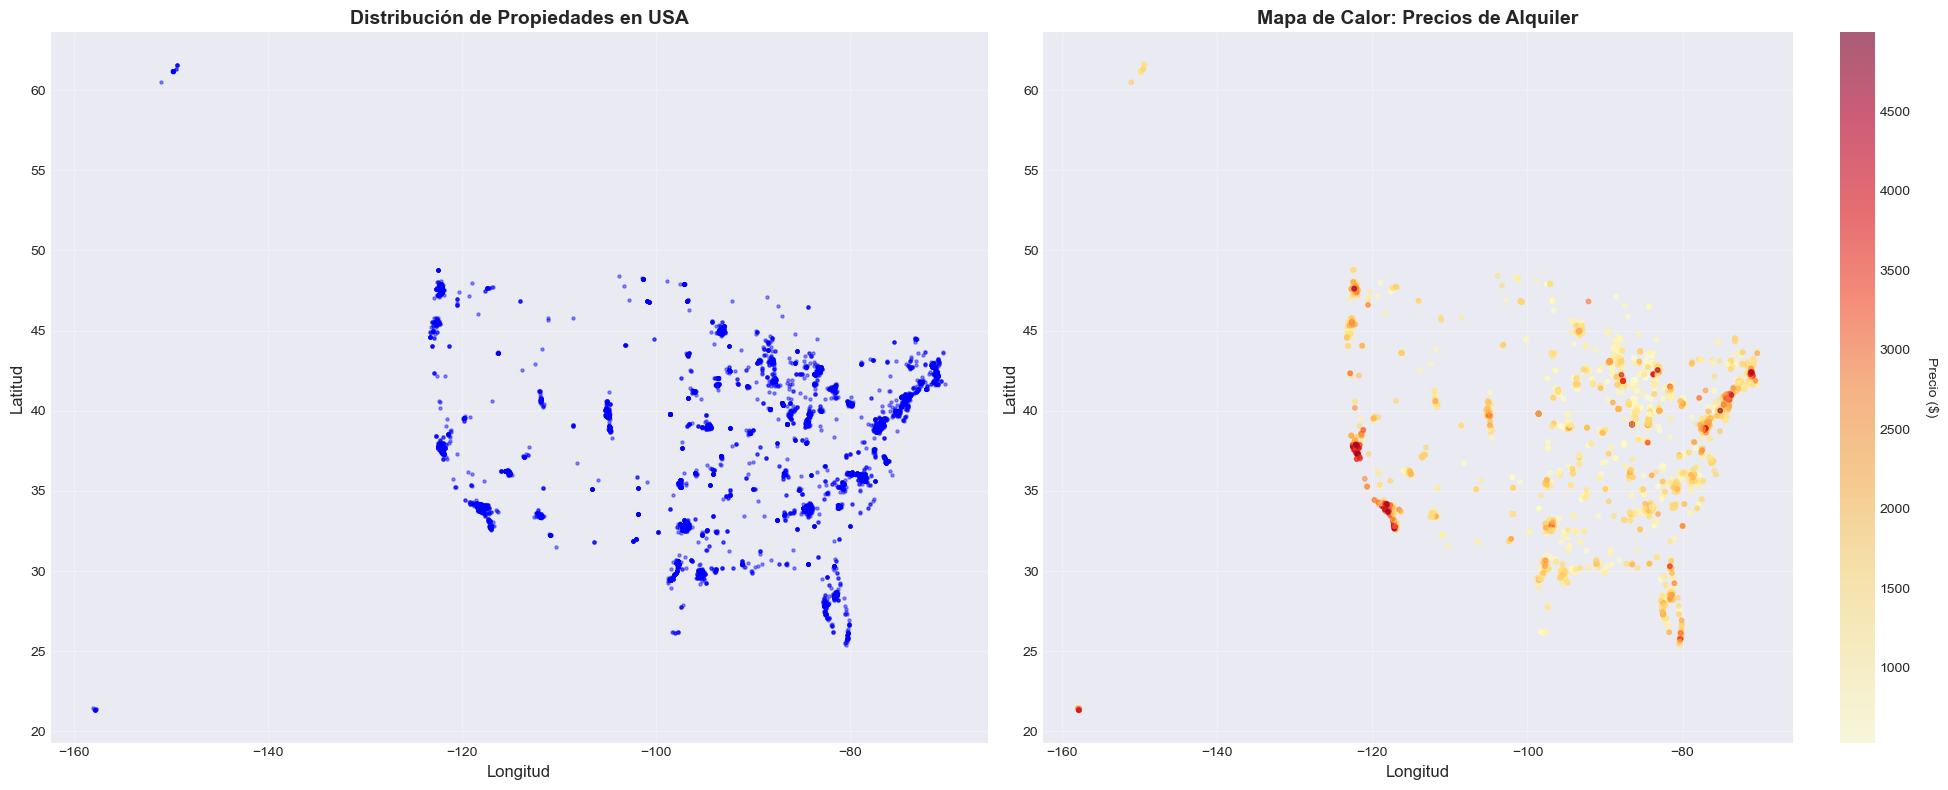

In [24]:
def mapa_simple_usa(df_clean):
    """
    Mapa simple de dispersión de propiedades en USA
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Mapa 1: Distribución de todas las propiedades
    scatter1 = axes[0].scatter(df_clean['longitude'], df_clean['latitude'],
                               c='blue', s=5, alpha=0.4)
    axes[0].set_xlabel('Longitud', fontsize=12)
    axes[0].set_ylabel('Latitud', fontsize=12)
    axes[0].set_title('Distribución de Propiedades en USA',
                      fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Mapa 2: Mapa de calor por densidad de precio
    scatter2 = axes[1].scatter(df_clean['longitude'], df_clean['latitude'],
                               c=df_clean['price'], cmap='YlOrRd',
                               s=10, alpha=0.6)
    axes[1].set_xlabel('Longitud', fontsize=12)
    axes[1].set_ylabel('Latitud', fontsize=12)
    axes[1].set_title('Mapa de Calor: Precios de Alquiler',
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter2, ax=axes[1])
    cbar.set_label('Precio ($)', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()

mapa_simple_usa(df_clean)

---
## 4. Pretratamiento de Datos

Realizaremos limpieza y transformación de los datos para prepararlos para el modelado.

In [11]:
# Crear copia de trabajo
df_clean = df.copy()

print('PRETRATAMIENTO DE DATOS')
print('='*80)

# 1. Eliminar duplicados
print('\n1. ELIMINACIÓN DE DUPLICADOS')
print('-'*80)
duplicados = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f'Duplicados eliminados: {duplicados}')
print(f'Filas restantes: {len(df_clean):,}')

PRETRATAMIENTO DE DATOS

1. ELIMINACIÓN DE DUPLICADOS
--------------------------------------------------------------------------------
Duplicados eliminados: 0
Filas restantes: 10,000


In [12]:
# 2. Tratamiento de valores nulos
print('\n2. TRATAMIENTO DE VALORES NULOS')
print('-'*80)

# Bedrooms: imputar con moda
if df_clean['bedrooms'].isnull().sum() > 0:
    moda_bedrooms = df_clean['bedrooms'].mode()[0]
    df_clean['bedrooms'].fillna(moda_bedrooms, inplace=True)
    print(f'✓ Bedrooms: imputados con moda ({moda_bedrooms})')

# Bathrooms: imputar con mediana por grupo de bedrooms
if df_clean['bathrooms'].isnull().sum() > 0:
    df_clean['bathrooms'] = df_clean.groupby('bedrooms')['bathrooms'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f'✓ Bathrooms: imputados con mediana por bedrooms')

# Coordenadas: eliminar filas (necesarias para clustering)
filas_antes = len(df_clean)
df_clean = df_clean.dropna(subset=['latitude', 'longitude'])
print(f'✓ Filas sin coordenadas eliminadas: {filas_antes - len(df_clean)}')

print(f'\nFilas después de tratar nulos: {len(df_clean):,}')


2. TRATAMIENTO DE VALORES NULOS
--------------------------------------------------------------------------------
✓ Bedrooms: imputados con moda (1.0)
✓ Bathrooms: imputados con mediana por bedrooms
✓ Filas sin coordenadas eliminadas: 10

Filas después de tratar nulos: 9,990


In [13]:
# 3. Tratamiento de outliers en precio
print('\n3. TRATAMIENTO DE OUTLIERS EN PRECIO')
print('-'*80)
Q1 = df_clean['price'].quantile(0.01)
Q3 = df_clean['price'].quantile(0.99)
filas_antes = len(df_clean)
df_clean = df_clean[(df_clean['price'] >= Q1) & (df_clean['price'] <= Q3)]
print(f'Outliers eliminados (percentiles 1% y 99%): {filas_antes - len(df_clean)}')
print(f'Nuevo rango de precios: ${df_clean["price"].min():.2f} - ${df_clean["price"].max():.2f}')

# 4. Tratamiento de outliers en square_feet
print('\n4. TRATAMIENTO DE OUTLIERS EN SQUARE FEET')
print('-'*80)
Q1_sf = df_clean['square_feet'].quantile(0.01)
Q3_sf = df_clean['square_feet'].quantile(0.99)
filas_antes = len(df_clean)
df_clean = df_clean[(df_clean['square_feet'] >= Q1_sf) & (df_clean['square_feet'] <= Q3_sf)]
print(f'Outliers eliminados: {filas_antes - len(df_clean)}')
print(f'Nuevo rango: {df_clean["square_feet"].min():.0f} - {df_clean["square_feet"].max():.0f} sq ft')

print(f'\n✓ Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


3. TRATAMIENTO DE OUTLIERS EN PRECIO
--------------------------------------------------------------------------------
Outliers eliminados (percentiles 1% y 99%): 193
Nuevo rango de precios: $530.00 - $4995.00

4. TRATAMIENTO DE OUTLIERS EN SQUARE FEET
--------------------------------------------------------------------------------
Outliers eliminados: 143
Nuevo rango: 250 - 2751 sq ft

✓ Dataset limpio: 9,654 filas × 22 columnas


In [14]:
# 5. Creación de variables derivadas (VÁLIDAS PARA PREDICCIÓN)
print('\n5. CREACIÓN DE VARIABLES DERIVADAS')
print('-'*80)
print('IMPORTANTE: Solo creamos features que NO dependen del precio')
print('para que sean válidas al momento de hacer predicciones.\n')

# Total de habitaciones
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']
print('✓ total_rooms = bedrooms + bathrooms')

# Categorización de bedrooms
df_clean['bedrooms_category'] = pd.cut(df_clean['bedrooms'], 
                                       bins=[-np.inf, 0, 1, 2, np.inf],
                                       labels=['Studio', '1BR', '2BR', '3+BR'])
print('✓ bedrooms_category: Studio / 1BR / 2BR / 3+BR')

# Variable binaria de mascotas
df_clean['pets_allowed_binary'] = df_clean['pets_allowed'].apply(
    lambda x: 1 if pd.notna(x) and x != 'None' else 0
)
print('✓ pets_allowed_binary: 0 = No, 1 = Sí')

print(f'\n✓ 3 variables derivadas creadas')
print(f'Dataset actual: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


5. CREACIÓN DE VARIABLES DERIVADAS
--------------------------------------------------------------------------------
IMPORTANTE: Solo creamos features que NO dependen del precio
para que sean válidas al momento de hacer predicciones.

✓ total_rooms = bedrooms + bathrooms
✓ bedrooms_category: Studio / 1BR / 2BR / 3+BR
✓ pets_allowed_binary: 0 = No, 1 = Sí

✓ 3 variables derivadas creadas
Dataset actual: 9,654 filas × 25 columnas


---
## 5. Clustering Geográfico (Feature Engineering Avanzado)

Aplicamos clustering para identificar **barrios** o zonas geográficas con características similares.

**IMPORTANTE:** Este clustering se basa SOLO en coordenadas geográficas (latitude, longitude), 
NO en precios. Por lo tanto, las features derivadas son válidas para predicción.

In [15]:
# Preparar datos geográficos
print('CLUSTERING GEOGRÁFICO')
print('='*80)
print('Basado SOLO en coordenadas geográficas (latitude, longitude)\n')

geo_data = df_clean[['latitude', 'longitude']].copy()

# Normalizar coordenadas
scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo_data)

print(f'Datos preparados: {len(geo_data):,} propiedades con coordenadas')

CLUSTERING GEOGRÁFICO
Basado SOLO en coordenadas geográficas (latitude, longitude)

Datos preparados: 9,654 propiedades con coordenadas


In [16]:
# Aplicar K-Means Clustering
print('\n1. K-MEANS CLUSTERING')
print('-'*80)

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_clean['neighborhood_cluster'] = kmeans.fit_predict(geo_scaled)

print(f'✓ {n_clusters} clusters (barrios) creados')
print(f'✓ Cada propiedad asignada a un barrio (0-{n_clusters-1})')

# Mostrar distribución
print('\nDistribución de propiedades por cluster:')
print(df_clean['neighborhood_cluster'].value_counts().sort_index())


1. K-MEANS CLUSTERING
--------------------------------------------------------------------------------
✓ 12 clusters (barrios) creados
✓ Cada propiedad asignada a un barrio (0-11)

Distribución de propiedades por cluster:
neighborhood_cluster
0     1573
1      354
2     1232
3      723
4      710
5      856
6     1104
7      325
8      803
9       43
10    1078
11     853
Name: count, dtype: int64


In [17]:
# Aplicar DBSCAN (detección de densidad)
print('\n2. DBSCAN - DETECCIÓN DE DENSIDAD')
print('-'*80)

dbscan = DBSCAN(eps=0.01, min_samples=5)
df_clean['density_cluster'] = dbscan.fit_predict(geo_scaled)

n_density_clusters = len(set(df_clean['density_cluster'])) - (1 if -1 in df_clean['density_cluster'].values else 0)
n_outliers = (df_clean['density_cluster'] == -1).sum()

print(f'✓ {n_density_clusters} clusters de densidad detectados')
print(f'✓ {n_outliers} puntos outliers (zonas de baja densidad)')


2. DBSCAN - DETECCIÓN DE DENSIDAD
--------------------------------------------------------------------------------
✓ 257 clusters de densidad detectados
✓ 1343 puntos outliers (zonas de baja densidad)


In [18]:
# Crear features agregadas del clustering (VÁLIDAS para predicción)
print('\n3. FEATURES DERIVADAS DEL CLUSTERING')
print('-'*80)
print('Estas features NO dependen del precio, solo de la ubicación geográfica\n')

# Tamaño del cluster (cantidad de propiedades en el barrio)
cluster_sizes = df_clean.groupby('neighborhood_cluster').size()
df_clean['cluster_size'] = df_clean['neighborhood_cluster'].map(cluster_sizes)
print('✓ cluster_size: número de propiedades en el mismo barrio')

# Distancia al centroide del cluster
centroids = kmeans.cluster_centers_
distances = []
for idx, row in df_clean.iterrows():
    cluster_id = row['neighborhood_cluster']
    geo_idx = geo_data.index.get_loc(idx)
    point = geo_scaled[geo_idx]
    centroid = centroids[cluster_id]
    dist = np.sqrt((point[0] - centroid[0])**2 + (point[1] - centroid[1])**2)
    distances.append(dist)

df_clean['distance_to_centroid'] = distances
print('✓ distance_to_centroid: qué tan lejos está del centro del barrio')

print(f'\n✓ Clustering completado')
print(f'Dataset final: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')


3. FEATURES DERIVADAS DEL CLUSTERING
--------------------------------------------------------------------------------
Estas features NO dependen del precio, solo de la ubicación geográfica

✓ cluster_size: número de propiedades en el mismo barrio
✓ distance_to_centroid: qué tan lejos está del centro del barrio

✓ Clustering completado
Dataset final: 9,654 filas × 29 columnas


In [19]:
# Estadísticas por cluster (para exploración)
print('\n4. ESTADÍSTICAS POR CLUSTER')
print('-'*80)

cluster_stats = df_clean.groupby('neighborhood_cluster').agg({
    'price': ['mean', 'median', 'count'],
    'square_feet': 'mean',
    'bedrooms': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).round(2)

cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.values]
print(cluster_stats)


4. ESTADÍSTICAS POR CLUSTER
--------------------------------------------------------------------------------
                      price_mean  price_median  price_count  square_feet_mean  bedrooms_mean  latitude_mean  \
neighborhood_cluster                                                                                          
0                        1712.60        1579.0         1573            882.45           1.61          40.42   
1                        2350.25        2222.5          354            911.27           1.70          38.52   
2                        1123.00        1032.0         1232            777.08           1.42          30.06   
3                        1160.57        1050.0          723            842.34           1.65          39.53   
4                        1642.91        1575.0          710            882.33           1.67          46.83   
5                        2015.04        1825.0          856            896.96           1.63          33.88   
6 

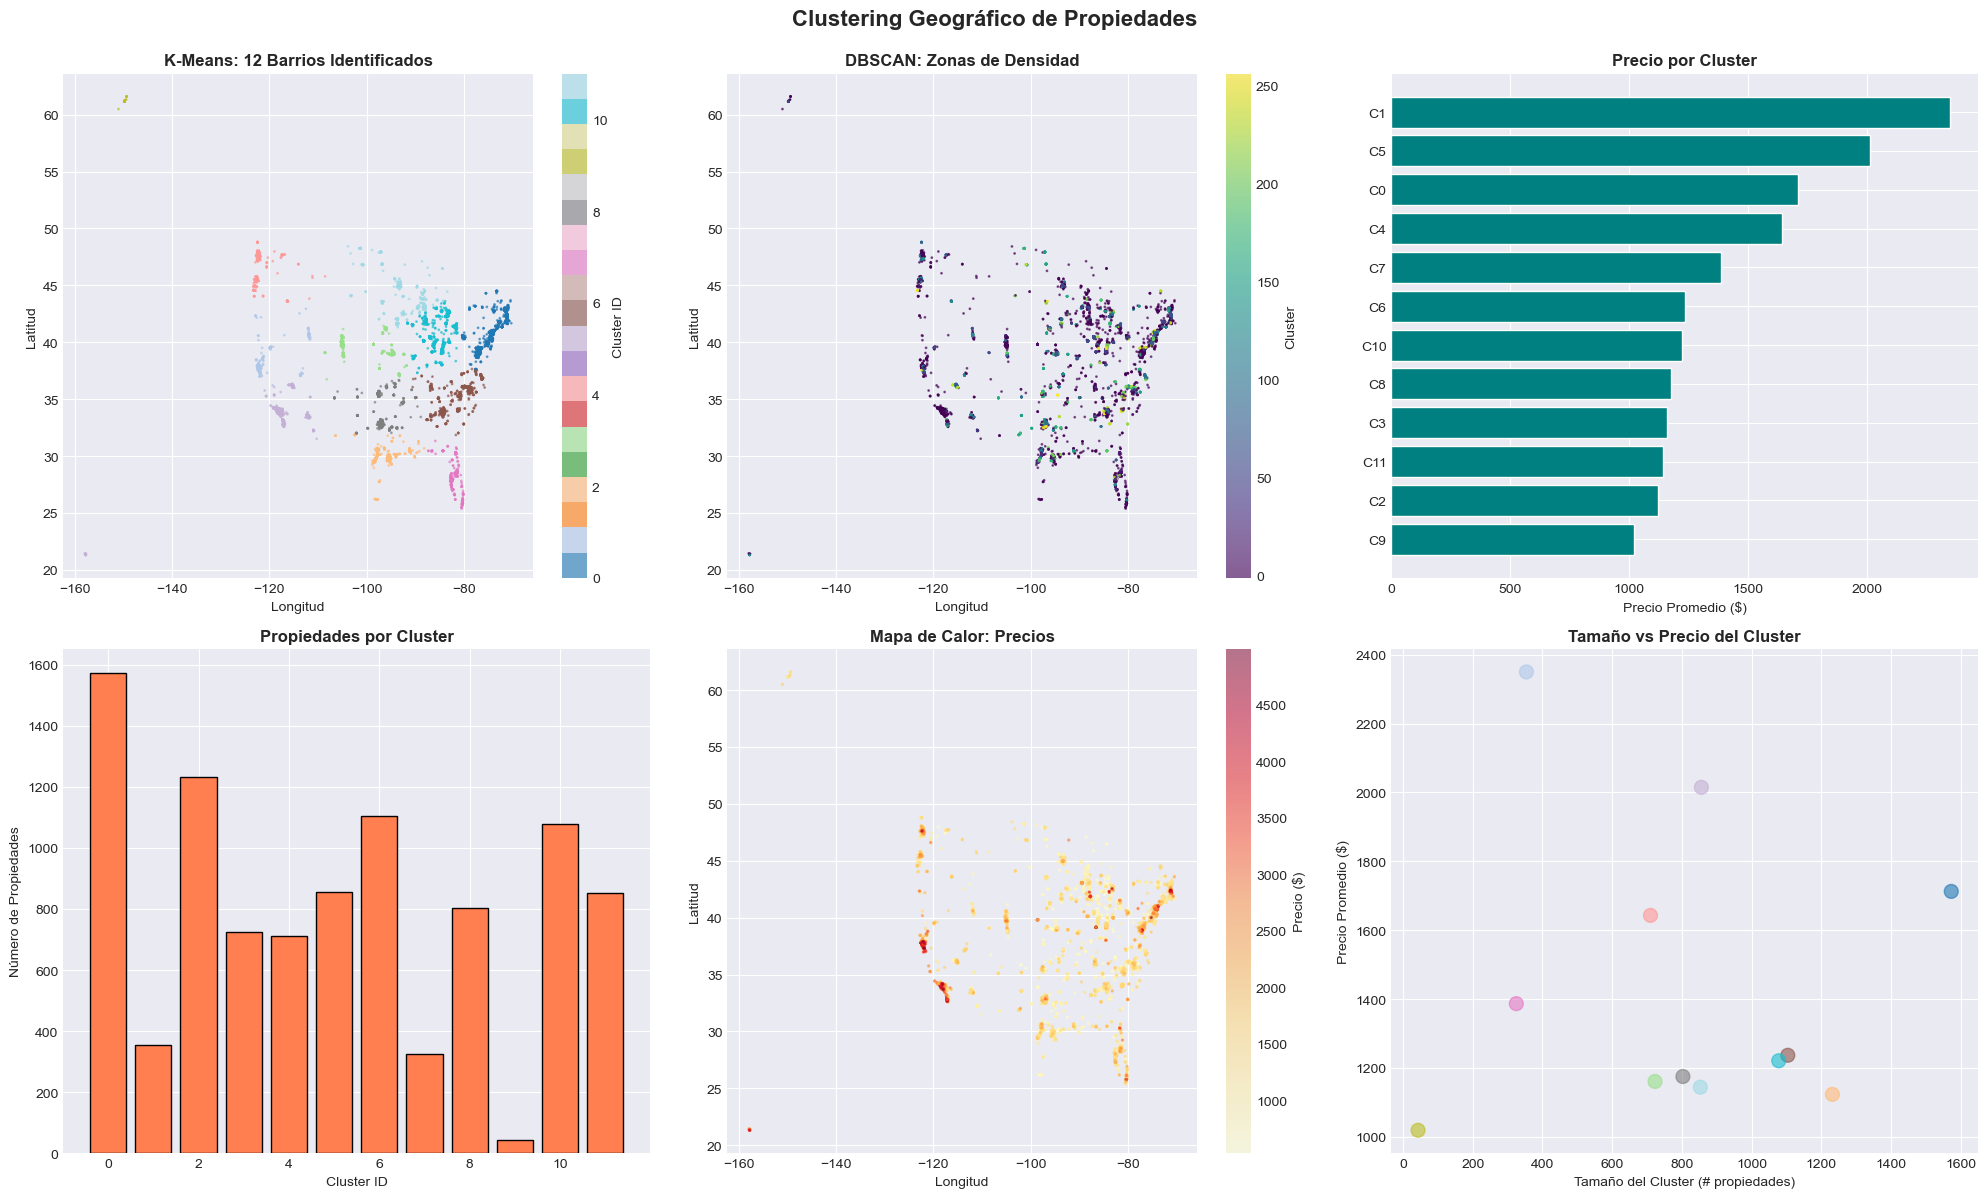

In [20]:
# Visualizaciones de clustering
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Clustering Geográfico de Propiedades', fontsize=16, fontweight='bold', y=0.995)

# 1. Mapa de clusters K-Means
scatter = axes[0, 0].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['neighborhood_cluster'], 
                            cmap='tab20', s=1, alpha=0.6)
axes[0, 0].set_xlabel('Longitud')
axes[0, 0].set_ylabel('Latitud')
axes[0, 0].set_title('K-Means: 12 Barrios Identificados', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster ID')

# 2. Mapa DBSCAN
scatter = axes[0, 1].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['density_cluster'], 
                            cmap='viridis', s=1, alpha=0.6)
axes[0, 1].set_xlabel('Longitud')
axes[0, 1].set_ylabel('Latitud')
axes[0, 1].set_title('DBSCAN: Zonas de Densidad', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1], label='Cluster')

# 3. Precio promedio por cluster
cluster_prices = df_clean.groupby('neighborhood_cluster')['price'].mean().sort_values()
axes[0, 2].barh(range(len(cluster_prices)), cluster_prices.values, color='teal')
axes[0, 2].set_yticks(range(len(cluster_prices)))
axes[0, 2].set_yticklabels([f'C{i}' for i in cluster_prices.index])
axes[0, 2].set_xlabel('Precio Promedio ($)')
axes[0, 2].set_title('Precio por Cluster', fontweight='bold')

# 4. Distribución de propiedades
cluster_counts = df_clean['neighborhood_cluster'].value_counts().sort_index()
axes[1, 0].bar(cluster_counts.index, cluster_counts.values, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Número de Propiedades')
axes[1, 0].set_title('Propiedades por Cluster', fontweight='bold')

# 5. Mapa de calor de precios
scatter = axes[1, 1].scatter(df_clean['longitude'], df_clean['latitude'], 
                            c=df_clean['price'], cmap='YlOrRd', s=2, alpha=0.5)
axes[1, 1].set_xlabel('Longitud')
axes[1, 1].set_ylabel('Latitud')
axes[1, 1].set_title('Mapa de Calor: Precios', fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1], label='Precio ($)')

# 6. Tamaño de cluster vs precio promedio
cluster_analysis = df_clean.groupby('neighborhood_cluster').agg({
    'price': 'mean',
    'cluster_size': 'first'
})
axes[1, 2].scatter(cluster_analysis['cluster_size'], cluster_analysis['price'], 
                  s=100, alpha=0.6, c=cluster_analysis.index, cmap='tab20')
axes[1, 2].set_xlabel('Tamaño del Cluster (# propiedades)')
axes[1, 2].set_ylabel('Precio Promedio ($)')
axes[1, 2].set_title('Tamaño vs Precio del Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

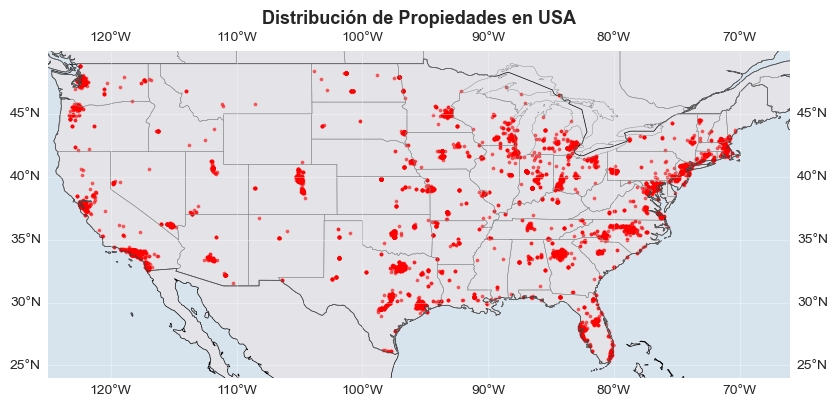

In [34]:
def mapa_con_cartopy(df_clean):

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(24, 16))

    # Mapa 1: Distribución simple
    ax1 = plt.subplot(2, 3, 1, projection=ccrs.PlateCarree())
    ax1.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())


    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')

    # Graficar propiedades
    ax1.scatter(df_clean['longitude'], df_clean['latitude'],
               c='red', s=3, alpha=0.5, transform=ccrs.PlateCarree())
    ax1.set_title('Distribución de Propiedades en USA', fontsize=13, fontweight='bold')
    ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)


    plt.tight_layout()
    plt.show()

mapa_con_cartopy(df_clean)

---
## 6. Análisis de Correlación

Analizamos las correlaciones entre variables numéricas y la variable objetivo (precio).

In [21]:
# Seleccionar variables numéricas relevantes
numerical_cols = [
    'price',              # Variable objetivo
    'bedrooms',           # Características físicas
    'bathrooms',
    'square_feet',
    'total_rooms',        # Variable derivada
    'pets_allowed_binary',
    'neighborhood_cluster',  # Clustering
    'cluster_size',
    'distance_to_centroid'
]

# Filtrar solo columnas que existen
numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

# Calcular matriz de correlación
correlation_matrix = df_clean[numerical_cols].corr()

# Mostrar correlaciones con precio
print('CORRELACIONES CON PRECIO')
print('='*80)
price_corr = correlation_matrix['price'].sort_values(ascending=False)
for col, corr in price_corr.items():
    if col != 'price':
        bar = '█' * int(abs(corr) * 50)
        sign = '+' if corr > 0 else '-'
        print(f'{col:30s} {sign} {abs(corr):.3f} {bar}')

CORRELACIONES CON PRECIO
square_feet                    + 0.394 ███████████████████
bathrooms                      + 0.369 ██████████████████
total_rooms                    + 0.347 █████████████████
bedrooms                       + 0.288 ██████████████
cluster_size                   - 0.019 
pets_allowed_binary            - 0.031 █
distance_to_centroid           - 0.113 █████
neighborhood_cluster           - 0.236 ███████████


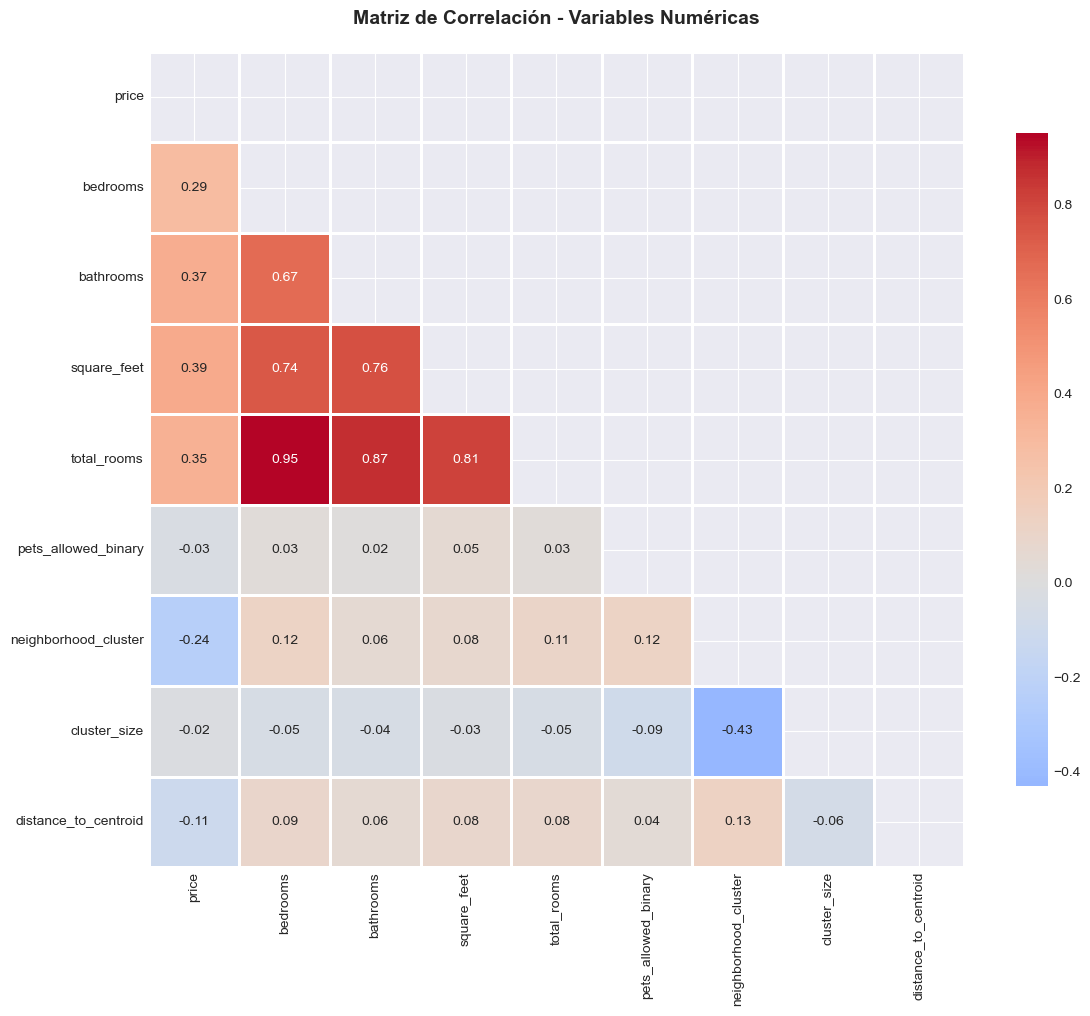

In [22]:
# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 7. Construcción de Modelo Predictivo (TO DO)

### Tareas Pendientes para la Versión Final:

#### 7.1 Preparación de Datos
- [ ] Codificar variables categóricas (state, cityname, bedrooms_category)
- [ ] Dividir dataset en train/test (80/20)
- [ ] Normalizar/estandarizar features numéricas
- [ ] Seleccionar features finales para el modelo

#### 7.2 Modelado
- [ ] **Modelo Baseline:** Regresión Lineal
- [ ] **Modelos Avanzados:**
  - Random Forest Regressor
  - Gradient Boosting (XGBoost o LightGBM)
  - Ridge/Lasso Regression
- [ ] Validación cruzada (k-fold CV)
- [ ] Optimización de hiperparámetros (GridSearchCV)

#### 7.3 Evaluación
- [ ] Calcular métricas en test set:
  - RMSE (Root Mean Squared Error)
  - MAE (Mean Absolute Error)
  - R² Score
  - MAPE (Mean Absolute Percentage Error)
- [ ] Comparar rendimiento de modelos
- [ ] Análisis de feature importance
- [ ] Gráficos de predicciones vs valores reales
- [ ] Análisis de residuos

---
## 8. Resultados Obtenidos (TO DO)

### Tareas Pendientes:

- [ ] Tabla comparativa de rendimiento entre modelos
- [ ] Gráfico de predicciones vs valores reales
- [ ] Distribución de errores (residuos)
- [ ] Identificación de mejores y peores predicciones
- [ ] Análisis de feature importance del mejor modelo
- [ ] Interpretación de resultados

---
## 9. Conclusiones

### Resumen del Trabajo Realizado:

1. **Análisis Exploratorio Completo**
   - Exploración de 10,000 registros de apartamentos en alquiler
   - Identificación de patrones geográficos y características del mercado
   - Análisis de distribuciones y outliers

2. **Pretratamiento Robusto**
   - Limpieza de datos y tratamiento de valores nulos
   - Eliminación de outliers usando percentiles
   - Dataset final: 9,654 registros (96.5% conservado)

3. **Feature Engineering Avanzado**
   - Creación de 3 variables derivadas básicas
   - **Clustering geográfico** con K-Means (12 barrios) y DBSCAN
   - Generación de 3 features adicionales del clustering
   - **IMPORTANTE:** Todas las features son válidas para predicción (no dependen del precio)

4. **Análisis de Correlación**
   - Identificación de variables más correlacionadas con precio
   - Visualización de relaciones entre variables

### Hallazgos Principales:

- **Concentración geográfica:** Texas (1,737), California (955) y Washington (519) lideran en cantidad de anuncios
- **Variabilidad de precios:** Rango de $530 a $4,995 después de limpieza
- **Clustering efectivo:** Se identificaron 12 barrios con características geográficas homogéneas
- **Variables más correlacionadas:** square_feet, bathrooms, total_rooms

### Próximos Pasos:

1. Codificar variables categóricas (state, cityname)
2. Implementar múltiples modelos de regresión
3. Optimizar hiperparámetros
4. Evaluar y comparar rendimiento
5. Seleccionar el mejor modelo para predicción de precios

### Nota Final:

Este proyecto demuestra la importancia del **clustering geográfico** como técnica de feature engineering. 
Las features derivadas de la ubicación geográfica pueden capturar información valiosa sobre el mercado local 
que no está presente en las características individuales de la propiedad.